In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
bms_df = pd.read_csv("runs/lmd_bms_results.csv", names=["num_evs", "num_tasks", "ev_range", "time"])
non_bms_df = pd.read_csv("runs/lmd_results.csv", names=["num_evs", "num_tasks", "ev_range", "time"])

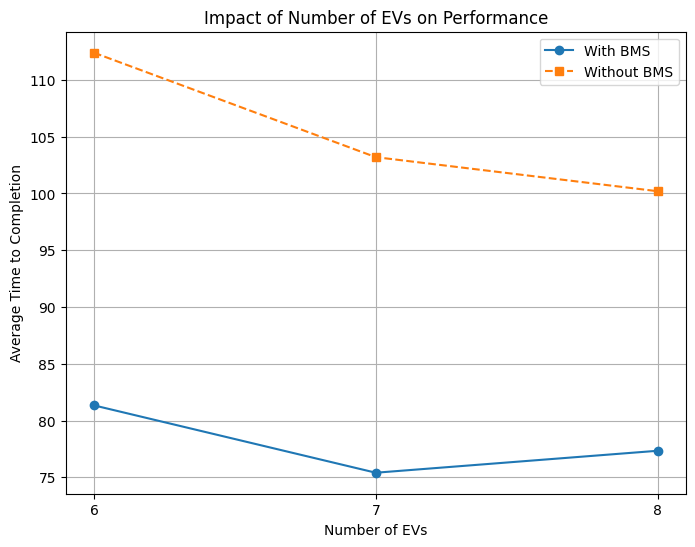

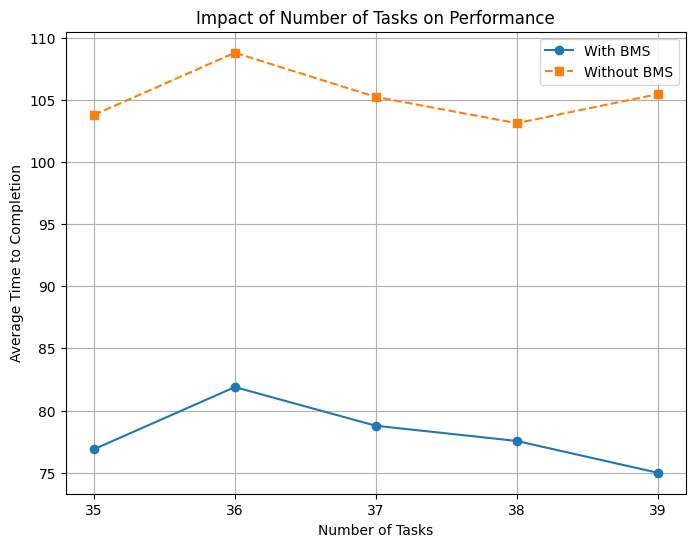

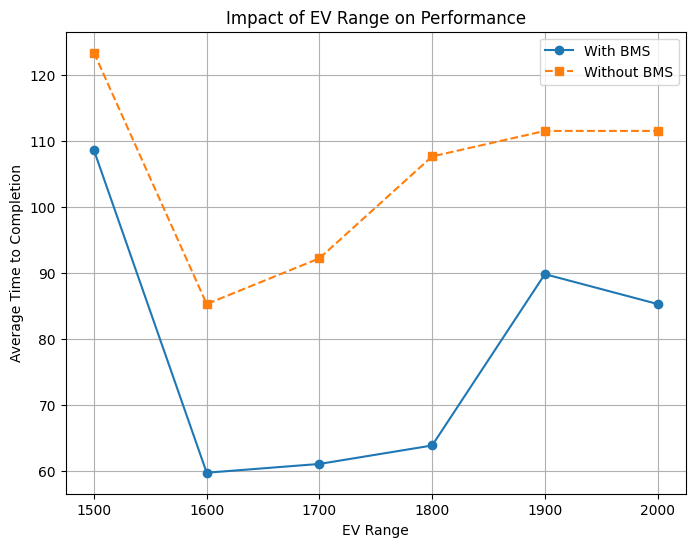

/tmp/ipykernel_21394/418406210.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["With BMS", "Without BMS"])


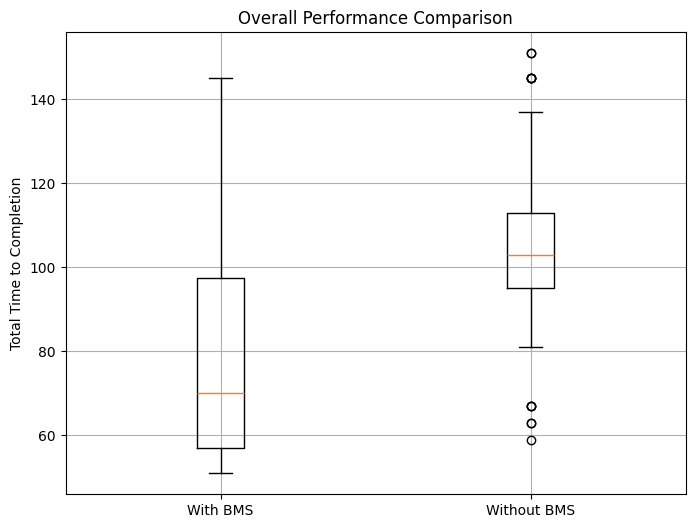

In [4]:

# Convert the time column to numeric; any non-numeric values will be set to NaN
bms_df["time"] = pd.to_numeric(bms_df["time"], errors="coerce")
non_bms_df["time"] = pd.to_numeric(non_bms_df["time"], errors="coerce")

# Function to compute average time for a given parameter while averaging over others
def get_avg_time(df, groupby_col):
    return df.groupby(groupby_col, as_index=False)["time"].mean()

# Compute averaged results for each parameter
bms_avg_evs = get_avg_time(bms_df, "num_evs")
non_bms_avg_evs = get_avg_time(non_bms_df, "num_evs")

bms_avg_tasks = get_avg_time(bms_df, "num_tasks")
non_bms_avg_tasks = get_avg_time(non_bms_df, "num_tasks")

bms_avg_range = get_avg_time(bms_df, "ev_range")
non_bms_avg_range = get_avg_time(non_bms_df, "ev_range")

# Plot 1: Number of EVs vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_evs["num_evs"], bms_avg_evs["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_evs["num_evs"], non_bms_avg_evs["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("Number of EVs")
plt.ylabel("Average Time to Completion")
plt.title("Impact of Number of EVs on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Number of Tasks vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_tasks["num_tasks"], bms_avg_tasks["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_tasks["num_tasks"], non_bms_avg_tasks["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("Number of Tasks")
plt.ylabel("Average Time to Completion")
plt.title("Impact of Number of Tasks on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: EV Range vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_range["ev_range"], bms_avg_range["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_range["ev_range"], non_bms_avg_range["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("EV Range")
plt.ylabel("Average Time to Completion")
plt.title("Impact of EV Range on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: Overall Performance Comparison (Boxplot)
plt.figure(figsize=(8, 6))
data = [bms_df["time"].dropna(), non_bms_df["time"].dropna()]
plt.boxplot(data, labels=["With BMS", "Without BMS"])
plt.ylabel("Total Time to Completion")
plt.title("Overall Performance Comparison")
plt.grid(True)
plt.show()
